# Lasso Regression

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

Linear regression has one job: make the error on the training rows small. Nothing stops
it from using a big slope.

Lasso has two jobs: make the error small **and** keep the slope small.

```text
LinearRegression : error only
Ridge            : error + alpha x (slope x slope)   slope gets small, never exactly 0
Lasso            : error + alpha x |slope|           slope can become exactly 0
```

### The formula

```text
   cost  =  (1 / 2n) x sum( y - y_pred )^2   +   alpha x |slope|
             \__________  __________/              \_____  _____/
                        \/                                \/
              how wrong the line is                price of the slope

   n     = number of training rows
   alpha = the price tag. You pick it, the data does not.
```

`alpha` small → a big slope is cheap → keep it.
`alpha` big → a big slope is expensive → cut it.

The data below is one input column, one output number, 10,000 rows, with noise added.

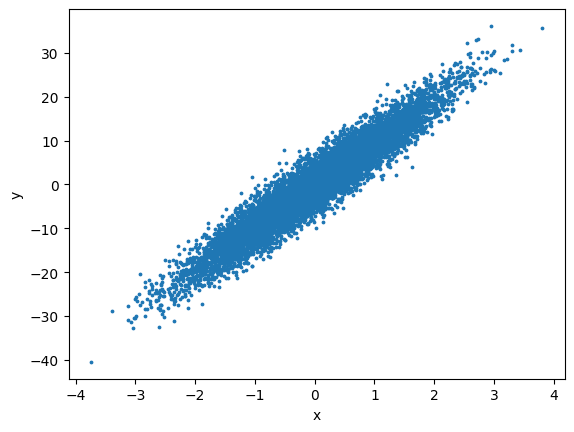

In [1]:
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, noise=3, n_samples=10000,random_state=0)
import matplotlib.pyplot as plt
plt.scatter(x,y,s=3)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0)

## 1. `Lasso()` — the default `alpha = 1`

Same three steps as always: `fit`, `predict`, `score`. `Lasso()` with no argument means
`alpha = 1.0`.

R² on the 2,000 hidden rows is **`0.8928`**.

In [3]:
from sklearn.linear_model import Lasso
reg = Lasso()
reg.fit(X_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [4]:
reg.predict(X_test)

array([  9.16411693,   4.79860515,   5.84348151, ...,   1.69826474,
        -6.30319338, -11.00609585], shape=(2000,))

In [5]:
reg.score(X_test, y_test)

0.8927723012288187

## 2. The model is two numbers

| | value | meaning |
|---|---|---|
| `coef_` | `8.532180` | `y` moves 8.53 when `x` moves 1 |
| `intercept_` | `-0.047383` | the height of the line at `x = 0` |

Plain `LinearRegression` on the same rows gives **`9.550322`**. So `alpha = 1` took about
`1.02` off the slope.

### The formula for one column

```text
   new slope  =  old slope  -  alpha x (n / S)      and it stops at 0

   n  = training rows                        = 8000
   S  = how spread out x is on those rows    = sum of (x - average x)^2 = 7857.45
   n / S                                     = 1.0181
```

So every `+1` of `alpha` **subtracts** `1.0181` from the slope.

That is the one difference from Ridge. Ridge *multiplies* the slope by a fraction, so it
never reaches 0. Lasso *subtracts*, so it can land on 0.

In [6]:
reg.coef_

array([8.53217994])

In [7]:
reg.intercept_

np.float64(-0.0473831581240432)

In [8]:
y_pred = reg.predict(x)

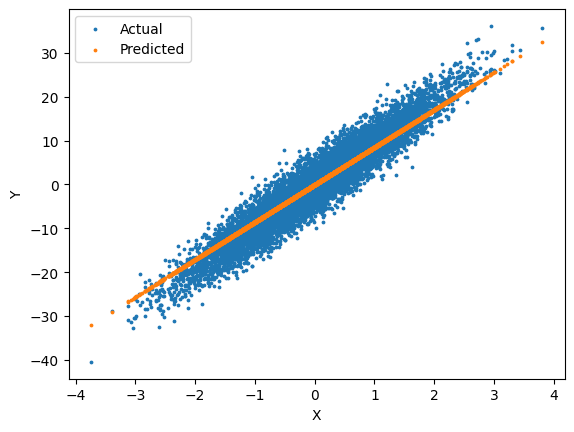

In [9]:
plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 3. Turning `alpha` up

The next cells are the same code with a bigger `alpha`. Each step is plain subtraction:

```text
   alpha = 1  ->  9.5503 - 1 x 1.0181  =  8.5322
   alpha = 2  ->  9.5503 - 2 x 1.0181  =  7.5140
   alpha = 5  ->  9.5503 - 5 x 1.0181  =  4.4596
   alpha = 7  ->  9.5503 - 7 x 1.0181  =  2.4233
   alpha = 9  ->  9.5503 - 9 x 1.0181  =  0.3870
```

Those are the numbers the cells actually print. The line goes flatter each time and the
score falls with it.

In [10]:
reg = Lasso(alpha=2)
reg.fit(X_train,y_train)
reg.score(X_test, y_test)

0.8626798290552528

In [11]:
reg.coef_

array([7.51403754])

In [12]:
y_pred = reg.predict(x)

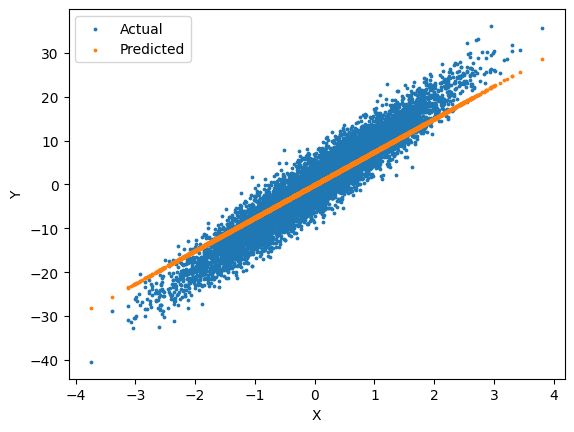

In [13]:
plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

0.6476800374760114
[4.45961036]


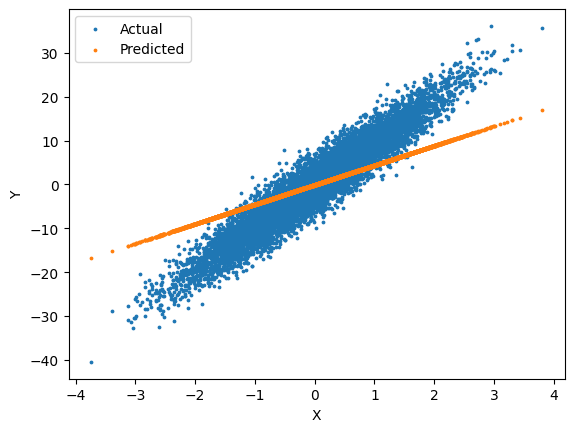

In [14]:
reg = Lasso(alpha=5)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

0.4004115305410644
[2.42332557]


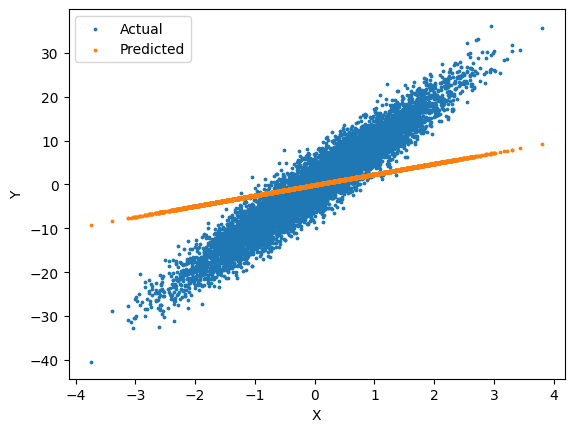

In [15]:
reg = Lasso(alpha=7)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

0.06999477356708794
[0.38704078]


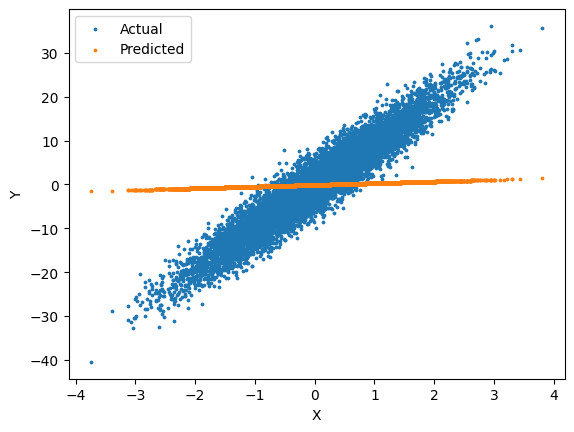

In [16]:
reg = Lasso(alpha=9)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 4. `alpha = 9.5` — the slope hits exactly 0

The formula would go negative here, so Lasso stops at 0:

```text
   9.5503 - 9.5 x 1.0181  =  -0.12   ->   0

   the alpha that kills the slope  =  old slope x S / n
                                   =  9.5503 x 7857.45 / 8000
                                   =  9.3801
```

Any `alpha` above `9.3801` gives `coef_ = [0.]`.

With no slope left, the line is flat and `intercept_` settles on the average of
`y_train` (`-0.110415`). The model predicts the same number for every row, so R² is
about 0 — that is exactly what R² = 0 means: no better than guessing the average.

**This is what Ridge cannot do.** Lasso removes a column completely.

-0.0022122517482792148
[0.]


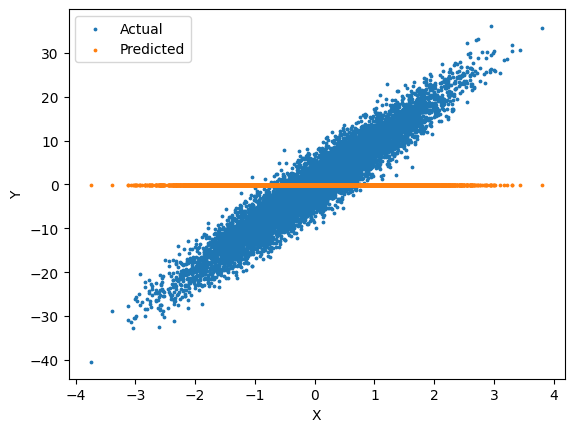

In [17]:
reg = Lasso(alpha=9.5)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 5. Going the other way

A small `alpha` is a small price, so the slope stays where linear regression put it.

| `alpha` | `coef_` | test R² |
|---:|---:|---:|
| `0.1` | `9.448508` | `0.902083` |
| `0.001` | `9.549304` | `0.902079` |
| `0.0001` | `9.550221` | `0.902078` |
| `0` | `9.550322` | `0.902078` |

`alpha = 0` **is** `LinearRegression`. Use that class for it — passing `alpha=0` to
`Lasso` works but sklearn warns about it.

0.9020825877391855
[9.44850809]


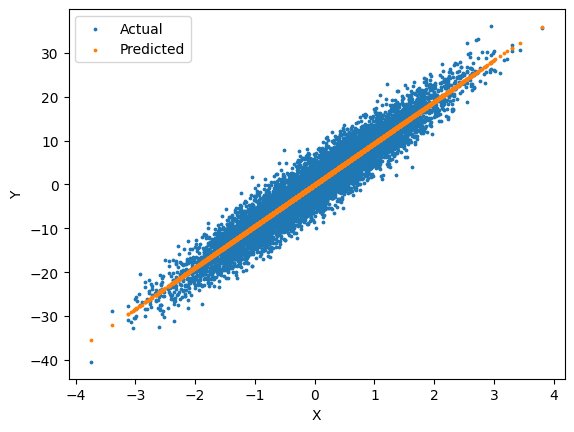

In [18]:
reg = Lasso(alpha=0.1)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

0.9020787886206871
[9.54930419]


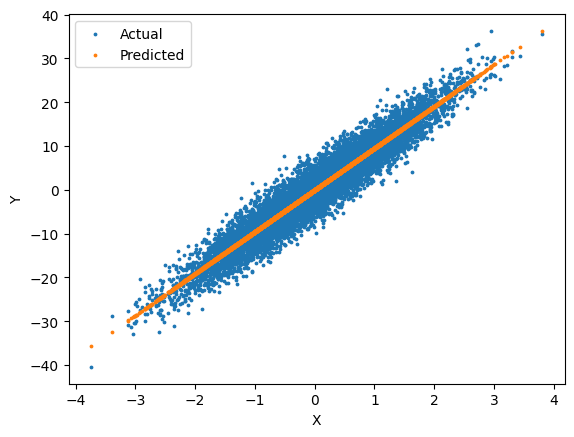

In [19]:
reg = Lasso(alpha=0.001)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

0.9020778196008511
[9.55022052]


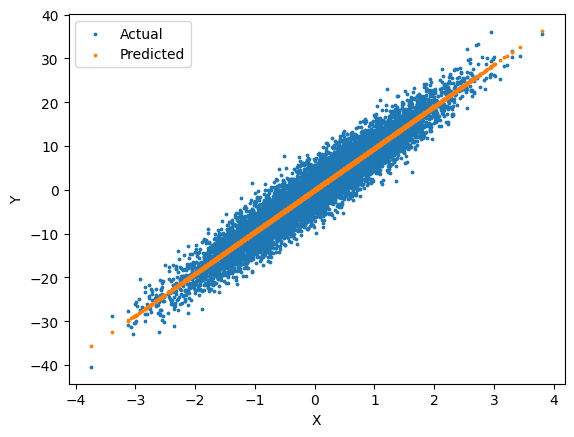

In [20]:
reg = Lasso(alpha=0.0001)
reg.fit(X_train,y_train)
print(reg.score(X_test, y_test))
print(reg.coef_)
y_pred = reg.predict(x)

plt.scatter(x,y,label='Actual',s=3)
plt.scatter(x,y_pred,label='Predicted',s=3)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 6. Wrap up

### The whole notebook in one table

| `alpha` | `coef_` | `intercept_` | test R² | what happened |
|---:|---:|---:|---:|---|
| `0` | `9.550322` | `-0.039862` | `0.902078` | plain `LinearRegression` |
| `0.0001` | `9.550221` | `-0.039862` | `0.902078` | no visible effect |
| `0.1` | `9.448508` | `-0.040614` | `0.902083` | 1% flatter, no cost |
| `1` | `8.532180` | `-0.047383` | `0.892772` | the default |
| `2` | `7.514038` | `-0.054905` | `0.862680` | a visible tilt |
| `5` | `4.459610` | `-0.077469` | `0.647680` | half gone |
| `7` | `2.423326` | `-0.092512` | `0.400412` | nearly flat |
| `9` | `0.387041` | `-0.107555` | `0.069995` | almost dead |
| **`9.3801`** | **`0.000000`** | `-0.110415` | `-0.002212` | **the slope is dropped** |
| `9.5` | `0.000000` | `-0.110415` | `-0.002212` | same, nothing left to cut |

The slope falls in a straight line, hits 0 at `9.3801`, and stays there.

### Lasso in three lines

```text
   cost       =  error  +  alpha x |slope|
   new slope  =  old slope  -  alpha x n/S       floored at 0
   alpha >= old slope x S/n   ->   slope = 0, the column is dropped
```

### Common mistakes

| Mistake | What actually happens |
|---|---|
| Copying an `alpha` from another project | `alpha` only means something next to `n / S`, and both change with your data. |
| Expecting Lasso to improve this model | It only helps when the model is overfitting. One clean column and 10,000 rows means there is nothing to fix, so every increase of `alpha` only makes the score worse. |
| Forgetting to scale the columns | Lasso charges every slope the same price. A column measured in millions gets a tiny slope and is dropped first, no matter how useful it is. Scale before you fit. |
| Using `Lasso(alpha=0)` | It is just `LinearRegression`, and sklearn warns. Use `LinearRegression`. |

### Key takeaway

**If you remember only one thing:** Ridge multiplies the slope down, Lasso subtracts it
down. Subtraction reaches zero — so Lasso does not just shrink a useless column, it
deletes it.